# Synthetic Tabular Data Generation

Synthetic data generation creates artificial datasets that **preserve the statistical properties** of real data without containing any real records. This is essential for:
- **Privacy protection**: Share data without exposing sensitive personal information
- **Data augmentation**: Expand small datasets for model training
- **Class balancing**: Generate minority class examples for imbalanced problems
- **Testing pipelines**: Build and test ML pipelines before production data is available
- **Regulatory compliance**: GDPR, HIPAA compliance while preserving utility

**Contents:**
1. Why Synthetic Data? Utility vs. Privacy Trade-off
2. Simple Statistical Baselines (Gaussian Copula)
3. SMOTE and Variants for Imbalanced Classification
4. CTGAN: Conditional Tabular GAN
5. Quality Evaluation: Statistical Fidelity & ML Utility
6. Privacy Evaluation: Membership Inference Risk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded')

Libraries loaded


## 1. Create a Realistic Tabular Dataset

We'll use a synthetic credit risk dataset with mixed types (numerical + categorical) and realistic correlations.

In [2]:
def make_credit_dataset(n=1000, seed=42):
    np.random.seed(seed)
    # Demographics
    age          = np.random.randint(18, 75, n)
    income       = np.random.lognormal(10.5, 0.6, n).clip(15000, 300000)
    employment   = np.random.choice(['employed','self_employed','unemployed'], n, p=[0.65,0.20,0.15])
    credit_score = (500 + age * 1.5 + np.log(income) * 10 + np.random.normal(0, 50, n)).clip(300, 850)
    loan_amount  = np.random.lognormal(9.5, 0.8, n).clip(1000, 100000)
    debt_to_inc  = np.random.beta(2, 5, n)  # 0-1
    num_accounts = np.random.poisson(3, n).clip(0, 15)
    # Target: default probability
    logit = -3 + 0.03*(700-credit_score) + 0.5*(employment=='unemployed').astype(float) + debt_to_inc*2 - np.log(income)/20
    prob_default = 1 / (1 + np.exp(-logit))
    default = (np.random.rand(n) < prob_default).astype(int)
    return pd.DataFrame({
        'age': age, 'income': income.astype(int), 'employment': employment,
        'credit_score': credit_score.astype(int), 'loan_amount': loan_amount.astype(int),
        'debt_to_income': debt_to_inc.round(3), 'num_accounts': num_accounts, 'default': default
    })

df_real = make_credit_dataset(1000)
print(df_real.head())
print(f'\nShape: {df_real.shape}')
print(f'Default rate: {df_real["default"].mean():.2%}')
print('\nData types:\n', df_real.dtypes)

   age  income  employment  credit_score  loan_amount  debt_to_income  \
0   56   15000    employed           685        13493           0.034   
1   69   34424    employed           737       100000           0.452   
2   46   16602  unemployed           764         3516           0.203   
3   32   54274  unemployed           578        31162           0.273   
4   60   45250    employed           778        11634           0.431   

   num_accounts  default  
0             3        0  
1             4        0  
2             5        0  
3             2        1  
4             4        0  

Shape: (1000, 8)
Default rate: 18.40%

Data types:
 age                 int64
income              int64
employment         object
credit_score        int64
loan_amount         int64
debt_to_income    float64
num_accounts        int64
default             int64
dtype: object


## 2. Gaussian Copula — Statistical Baseline

**Gaussian Copula** separates marginal distributions from their dependency structure:
1. Transform each column to uniform marginals via the empirical CDF
2. Transform to standard normal using inverse CDF
3. Estimate correlation matrix in the normal space
4. Sample from multivariate normal with that correlation
5. Transform back to original marginals

This preserves pairwise correlations but not higher-order dependencies.

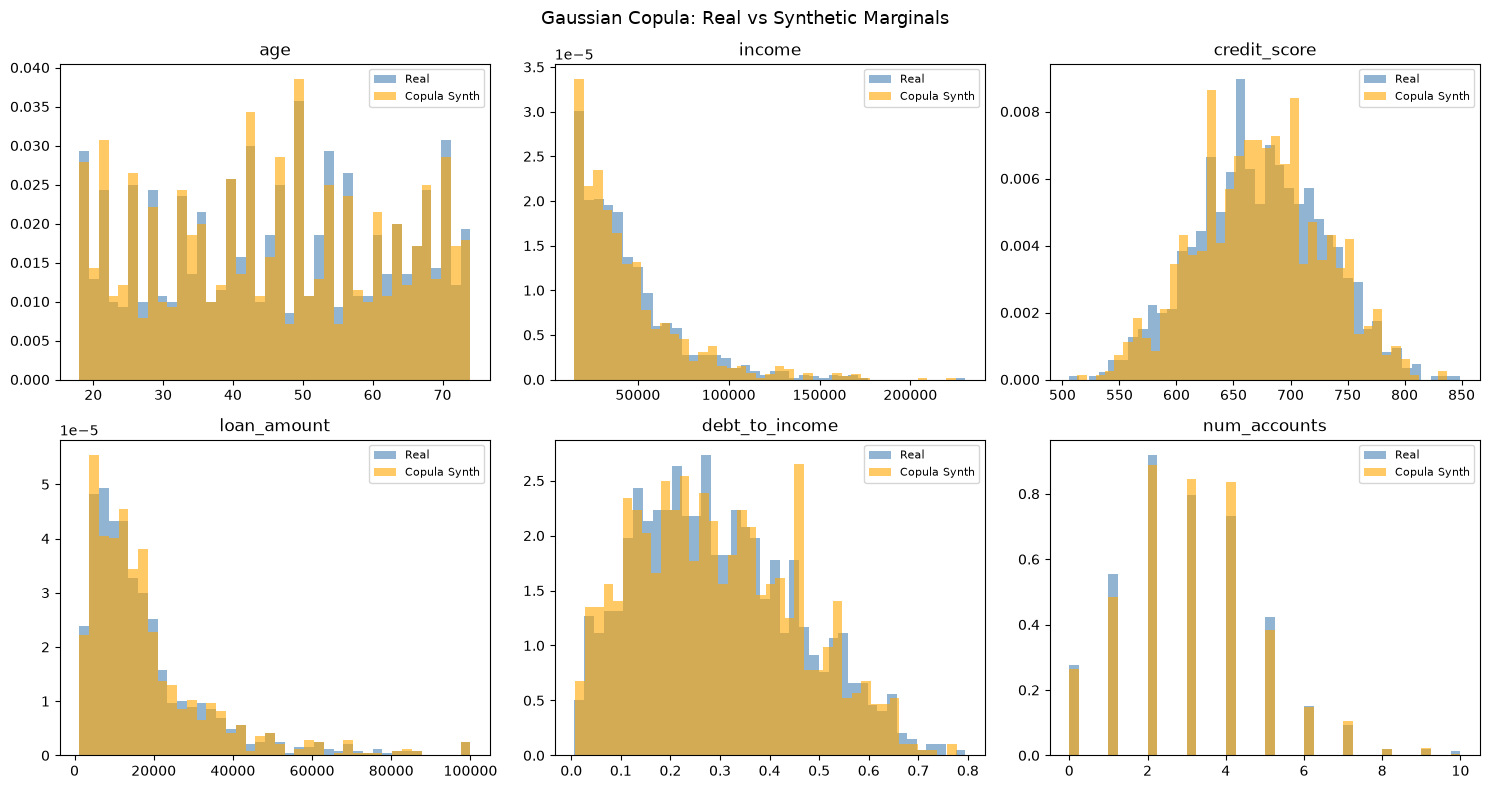

Gaussian Copula synthetic data generated


In [3]:
from scipy.stats import norm

def gaussian_copula_sample(df_num, n_samples):
    """Gaussian copula for numerical columns."""
    from scipy.stats import rankdata
    n, d = df_num.shape
    # Step 1: Empirical CDF -> uniform marginals
    U = np.column_stack([rankdata(df_num.iloc[:, i]) / (n + 1) for i in range(d)])
    # Step 2: Uniform -> standard normal
    Z = norm.ppf(U)
    # Step 3: Estimate correlation
    corr = np.corrcoef(Z, rowvar=False)
    # Step 4: Sample from MVN
    Z_syn = np.random.multivariate_normal(np.zeros(d), corr, n_samples)
    # Step 5: Back to original marginals via quantile mapping
    U_syn = norm.cdf(Z_syn)
    X_syn = np.column_stack([
        np.quantile(df_num.iloc[:, i], U_syn[:, i])
        for i in range(d)
    ])
    return pd.DataFrame(X_syn, columns=df_num.columns)

num_cols = ['age','income','credit_score','loan_amount','debt_to_income','num_accounts']
df_synth_copula = gaussian_copula_sample(df_real[num_cols], n_samples=1000)
# Round integer-like columns
for col in ['age','income','credit_score','loan_amount','num_accounts']:
    df_synth_copula[col] = df_synth_copula[col].round().astype(int)

# Compare distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df_real[col], bins=40, alpha=0.6, density=True, label='Real', color='steelblue')
    ax.hist(df_synth_copula[col], bins=40, alpha=0.6, density=True, label='Copula Synth', color='orange')
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle('Gaussian Copula: Real vs Synthetic Marginals', fontsize=13)
plt.tight_layout(); plt.show()
print('Gaussian Copula synthetic data generated')

## 3. SMOTE — Synthetic Minority Oversampling

**SMOTE (Synthetic Minority Over-sampling TEchnique)** creates new minority class samples by interpolating between existing samples in feature space:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{\text{nn}} - x_i), \quad \lambda \sim \text{Uniform}(0,1)$$

where $x_{\text{nn}}$ is a random k-nearest neighbour of $x_i$ from the minority class.

**Variants:** ADASYN (adaptive density), BorderlineSMOTE (focus on boundary), SVMSMOTE

Class distribution before SMOTE: {np.int64(0): np.int64(945), np.int64(1): np.int64(55)}
Class distribution after SMOTE:  {np.int64(0): np.int64(945), np.int64(1): np.int64(945)}


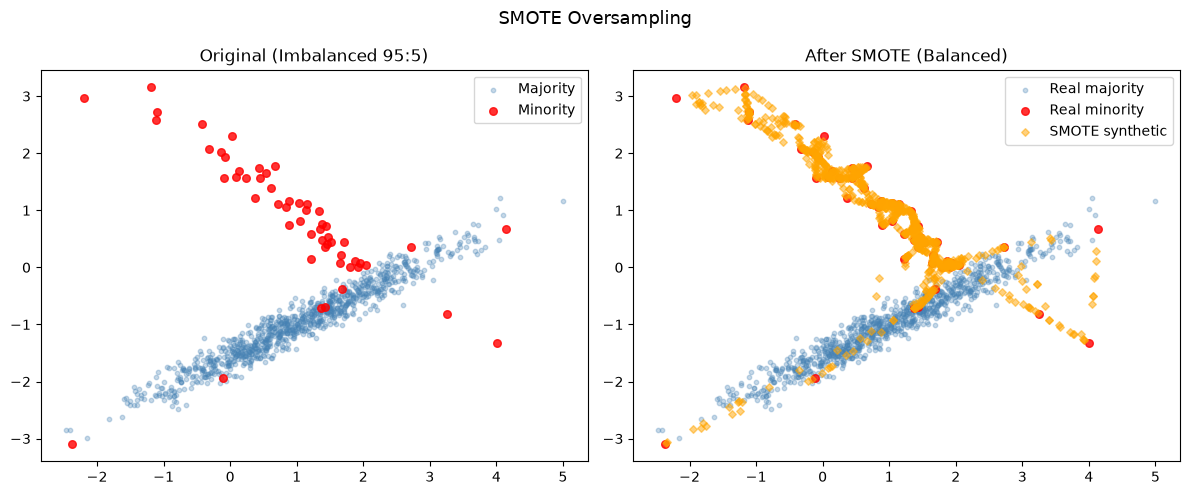

In [4]:
# Create a highly imbalanced binary dataset for demo
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.95, 0.05], random_state=42, n_clusters_per_class=1
)
print(f'Class distribution before SMOTE: {dict(zip(*np.unique(y_imb, return_counts=True)))}')

# Manual SMOTE implementation
from sklearn.neighbors import NearestNeighbors

def smote(X_min, k=5, n_synthetic=None):
    if n_synthetic is None:
        n_synthetic = len(X_min)
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    distances, indices = nbrs.kneighbors(X_min)
    synthetic = []
    for _ in range(n_synthetic):
        i     = np.random.randint(len(X_min))
        nn    = indices[i, 1 + np.random.randint(k)]  # skip self
        lam   = np.random.rand()
        synthetic.append(X_min[i] + lam * (X_min[nn] - X_min[i]))
    return np.array(synthetic)

X_min = X_imb[y_imb == 1]
X_maj = X_imb[y_imb == 0]
n_needed = len(X_maj) - len(X_min)
X_synthetic = smote(X_min, k=5, n_synthetic=n_needed)

X_balanced = np.vstack([X_imb, X_synthetic])
y_balanced = np.concatenate([y_imb, np.ones(n_needed, dtype=int)])
print(f'Class distribution after SMOTE:  {dict(zip(*np.unique(y_balanced, return_counts=True)))}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(*X_imb[y_imb==0].T, alpha=0.3, s=10, c='steelblue', label='Majority')
axes[0].scatter(*X_imb[y_imb==1].T, alpha=0.8, s=30, c='red', label='Minority')
axes[0].set_title('Original (Imbalanced 95:5)'); axes[0].legend()
axes[1].scatter(*X_maj.T, alpha=0.3, s=10, c='steelblue', label='Real majority')
axes[1].scatter(*X_min.T, alpha=0.8, s=30, c='red', label='Real minority')
axes[1].scatter(*X_synthetic.T, alpha=0.5, s=15, c='orange', marker='D', label='SMOTE synthetic')
axes[1].set_title('After SMOTE (Balanced)'); axes[1].legend()
plt.suptitle('SMOTE Oversampling', fontsize=13)
plt.tight_layout(); plt.show()

In [5]:
# Compare classifiers with/without SMOTE
from sklearn.linear_model import LogisticRegression

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, random_state=0, stratify=y_imb)

# Without SMOTE
clf_no = LogisticRegression(random_state=0).fit(X_tr, y_tr)
y_pred_no = clf_no.predict(X_te)

# With SMOTE (on train only)
X_min_tr = X_tr[y_tr == 1]; X_maj_tr = X_tr[y_tr == 0]
n_need_tr = len(X_maj_tr) - len(X_min_tr)
X_smote_tr = smote(X_min_tr, k=5, n_synthetic=n_need_tr)
X_tr_bal = np.vstack([X_tr, X_smote_tr])
y_tr_bal = np.concatenate([y_tr, np.ones(n_need_tr)])
clf_sm = LogisticRegression(random_state=0).fit(X_tr_bal, y_tr_bal)
y_pred_sm = clf_sm.predict(X_te)

print('--- Without SMOTE ---')
print(classification_report(y_te, y_pred_no, digits=3))
print('--- With SMOTE ---')
print(classification_report(y_te, y_pred_sm, digits=3))

--- Without SMOTE ---
              precision    recall  f1-score   support

           0      0.990     1.000     0.995       284
           1      1.000     0.812     0.897        16

    accuracy                          0.990       300
   macro avg      0.995     0.906     0.946       300
weighted avg      0.990     0.990     0.990       300

--- With SMOTE ---
              precision    recall  f1-score   support

           0      1.000     0.951     0.975       284
           1      0.533     1.000     0.696        16

    accuracy                          0.953       300
   macro avg      0.767     0.975     0.835       300
weighted avg      0.975     0.953     0.960       300



## 4. CTGAN — Conditional Tabular GAN

**CTGAN** is specifically designed for tabular data with:
- **Mode-specific normalisation**: handles multi-modal continuous distributions via VGM
- **Conditional generation**: can generate samples conditioned on discrete columns
- **Training-by-sampling**: balances training on minority categories

Architecture: Generator maps noise + condition vector → synthetic row; Discriminator distinguishes real vs. synthetic.

In [6]:
from ctgan import CTGAN
print(f'CTGAN imported successfully')

# Prepare a smaller dataset for faster training
df_train_ctgan = df_real.copy()
df_train_ctgan['default'] = df_train_ctgan['default'].astype(str)  # treat as categorical

discrete_cols = ['employment', 'default']

# Train CTGAN (use fewer epochs for speed; 100 is reasonable for a demo)
synthesizer = CTGAN(
    epochs=100,
    batch_size=500,
    verbose=False
)
synthesizer.fit(df_train_ctgan, discrete_columns=discrete_cols)
print('CTGAN training complete')

# Generate synthetic data
df_ctgan_synth = synthesizer.sample(1000)
df_ctgan_synth['default'] = df_ctgan_synth['default'].astype(int)
print(f'Synthetic data shape: {df_ctgan_synth.shape}')
print('Synthetic employment distribution:')
print(df_ctgan_synth['employment'].value_counts(normalize=True).round(3))
print('\nReal employment distribution:')
print(df_real['employment'].value_counts(normalize=True).round(3))

CTGAN imported successfully


CTGAN training complete
Synthetic data shape: (1000, 8)
Synthetic employment distribution:
employment
employed         0.508
self_employed    0.250
unemployed       0.242
Name: proportion, dtype: float64

Real employment distribution:
employment
employed         0.655
self_employed    0.201
unemployed       0.144
Name: proportion, dtype: float64


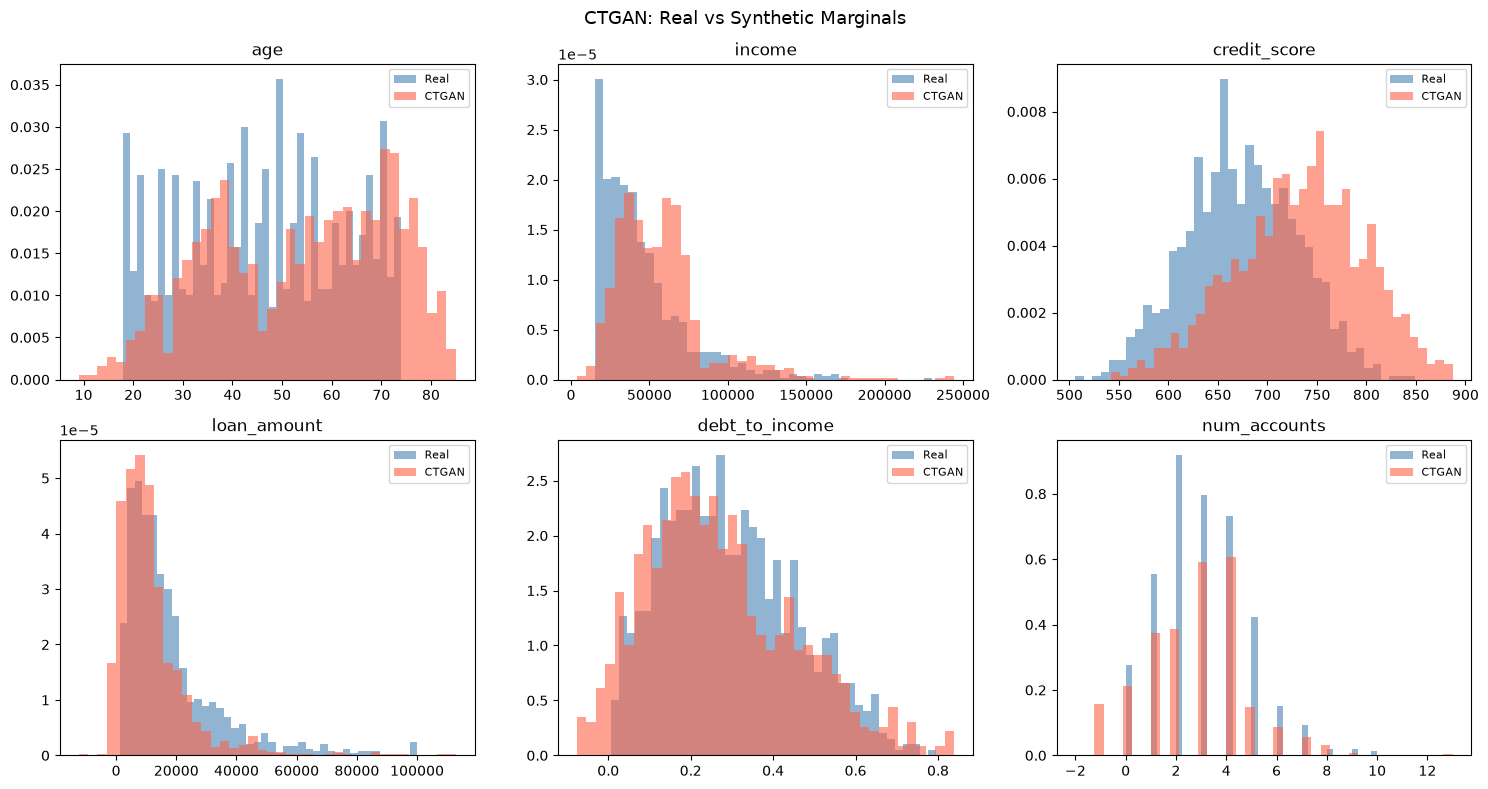

In [7]:
# Visual comparison: Real vs CTGAN
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df_real[col], bins=40, alpha=0.6, density=True, label='Real', color='steelblue')
    synth_col = pd.to_numeric(df_ctgan_synth[col], errors='coerce').dropna()
    ax.hist(synth_col, bins=40, alpha=0.6, density=True, label='CTGAN', color='tomato')
    ax.set_title(col); ax.legend(fontsize=8)

plt.suptitle('CTGAN: Real vs Synthetic Marginals', fontsize=13)
plt.tight_layout(); plt.show()

## 5. Quality Evaluation: Statistical Fidelity & ML Utility

Two key axes for evaluating synthetic data:

**Statistical Fidelity**: How well does the synthetic data reproduce the statistical properties of real data?
- Column-by-column distribution comparison (KS test, Wasserstein distance)
- Correlation matrix similarity

**ML Utility (Train-Synthetic, Test-Real)**: Can a model trained on synthetic data perform well on real data?
- Train on synthetic → Test on real
- Compare to Train-Real, Test-Real (upper bound)

In [8]:
from scipy.stats import ks_2samp, wasserstein_distance

def evaluate_fidelity(real_df, synth_df, num_cols):
    rows = []
    for col in num_cols:
        r = pd.to_numeric(real_df[col], errors='coerce').dropna().values
        s = pd.to_numeric(synth_df[col], errors='coerce').dropna().values
        ks_stat, ks_p = ks_2samp(r, s)
        wass = wasserstein_distance(r / (r.std() + 1e-9), s / (s.std() + 1e-9))
        rows.append({'column': col, 'KS_stat': ks_stat, 'KS_pvalue': ks_p, 'Wasserstein': wass})
    return pd.DataFrame(rows)

print('=== Gaussian Copula Fidelity ===')
fid_copula = evaluate_fidelity(df_real, df_synth_copula, num_cols)
print(fid_copula.round(4).to_string(index=False))

print('\n=== CTGAN Fidelity ===')
fid_ctgan = evaluate_fidelity(df_real, df_ctgan_synth, num_cols)
print(fid_ctgan.round(4).to_string(index=False))

=== Gaussian Copula Fidelity ===
        column  KS_stat  KS_pvalue  Wasserstein
           age    0.022     0.9690       0.0642
        income    0.044     0.2878       0.0759
  credit_score    0.026     0.8882       0.2925
   loan_amount    0.021     0.9803       0.0246
debt_to_income    0.026     0.8882       0.0399
  num_accounts    0.029     0.7947       0.0860

=== CTGAN Fidelity ===
        column  KS_stat  KS_pvalue  Wasserstein
           age    0.195     0.0000       0.1928
        income    0.252     0.0000       0.3669
  credit_score    0.385     0.0000       0.7677
   loan_amount    0.216     0.0000       0.2355
debt_to_income    0.094     0.0003       0.3553
  num_accounts    0.072     0.0112       0.3303


In [9]:
# ML Utility: Train-Synthetic Test-Real
from sklearn.preprocessing import OrdinalEncoder

feature_cols = ['age','income','credit_score','loan_amount','debt_to_income','num_accounts','employment']

def prep_xy(df):
    d = df[feature_cols + ['default']].copy()
    d['employment'] = OrdinalEncoder().fit_transform(d[['employment']])
    return d[feature_cols].values.astype(float), d['default'].values.astype(int)

X_real, y_real = prep_xy(df_real)

# Copula only generates numeric columns; re-generate employment/default from those features
df_copula_full = df_synth_copula.copy()
df_copula_full['employment'] = np.random.choice(
    ['employed','self_employed','unemployed'], len(df_copula_full), p=[0.65,0.20,0.15])
logit_c = -3 + 0.03*(700 - df_copula_full['credit_score']) + df_copula_full['debt_to_income']*2 - np.log(np.abs(df_copula_full['income'])+1)/20
prob_c  = 1 / (1 + np.exp(-logit_c))
df_copula_full['default'] = (np.random.rand(len(df_copula_full)) < prob_c).astype(int)
X_copula, y_copula = prep_xy(df_copula_full)

# CTGAN synthetic
df_ctgan_num = df_ctgan_synth.copy()
for c in num_cols:
    df_ctgan_num[c] = pd.to_numeric(df_ctgan_num[c], errors='coerce').fillna(df_real[c].median())
X_ctgan, y_ctgan = prep_xy(df_ctgan_num)

# Split real data for test
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_real, y_real, test_size=0.3, random_state=42)

results_util = {}
for name, Xtr, ytr in [('Real→Real (upper bound)', X_tr_r, y_tr_r),
                        ('CTGAN→Real', X_ctgan, y_ctgan),
                        ('Copula→Real', X_copula, y_copula)]:
    try:
        if len(np.unique(ytr)) < 2:
            print(f'{name:<30}: SKIP — single class in synthetic target')
            continue
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(Xtr, ytr)
        y_prob = clf.predict_proba(X_te_r)[:, 1]
        auc = roc_auc_score(y_te_r, y_prob)
        results_util[name] = auc
        print(f'{name:<30}: AUC = {auc:.4f}')
    except Exception as e:
        print(f'{name:<30}: ERROR - {e}')

print('\nML Utility measures how well a model trained on synthetic data generalises to real data.')
print('A score close to "Real→Real" means high utility.')

Real→Real (upper bound)       : AUC = 0.8168


CTGAN→Real                    : AUC = 0.4292


Copula→Real                   : AUC = 0.8484

ML Utility measures how well a model trained on synthetic data generalises to real data.
A score close to "Real→Real" means high utility.


## 6. Correlation Structure Preservation

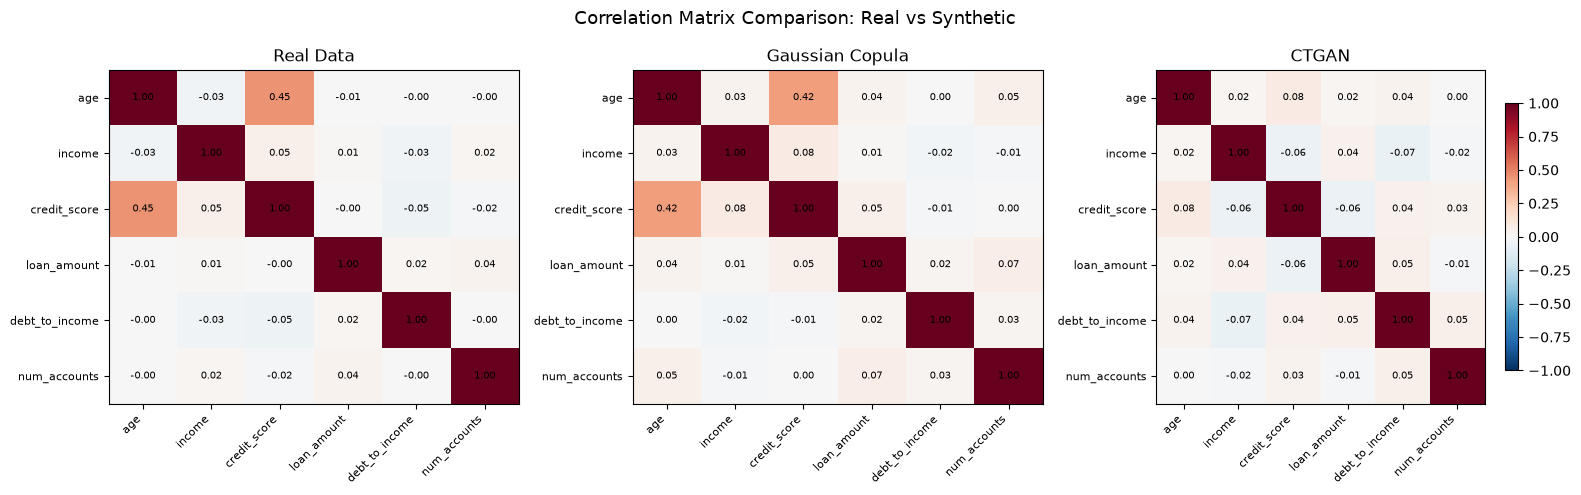

Gaussian Copula preserves pairwise correlations by design.
CTGAN should also preserve them if training converged well.


In [10]:
import matplotlib

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datasets = [
    ('Real Data', df_real[num_cols]),
    ('Gaussian Copula', df_synth_copula[num_cols]),
    ('CTGAN', df_ctgan_synth[num_cols].apply(pd.to_numeric, errors='coerce')),
]

for ax, (name, data) in zip(axes, datasets):
    corr = data.corr()
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=8)
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
    ax.set_title(name)

plt.colorbar(im, ax=axes[-1], shrink=0.8)
plt.suptitle('Correlation Matrix Comparison: Real vs Synthetic', fontsize=13)
plt.tight_layout(); plt.show()
print('Gaussian Copula preserves pairwise correlations by design.')
print('CTGAN should also preserve them if training converged well.')

## 7. Privacy Evaluation: Membership Inference Risk

A **membership inference attack** tries to determine whether a specific real record was used in training the generator. High risk means the model memorised training examples.

Simple metric: **Nearest-Neighbour Distance Ratio (NNDR)**. For each synthetic record, compute:
$$\text{NNDR}_i = \frac{\text{dist}(x_i^{\text{syn}}, \text{nearest real})}{\text{dist}(x_i^{\text{syn}}, \text{second nearest real})}$$

Low NNDR (close to 0) = synthetic point is very close to a single real point → privacy risk.
High NNDR (close to 1) = equidistant between two real points → safe interpolation.

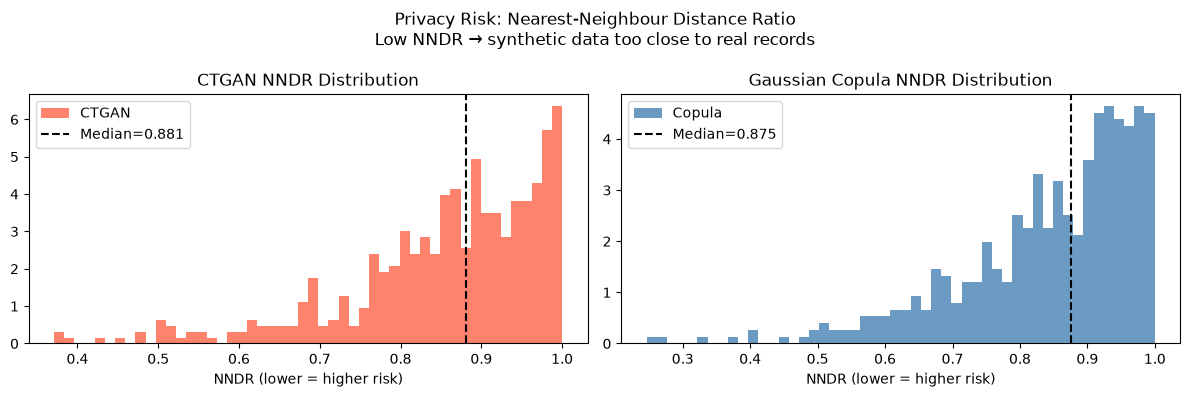

CTGAN: 0.00% of synthetic points within 0.1 NNDR of a real record
Copula: 0.00% of synthetic points within 0.1 NNDR of a real record


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

def nndr_privacy_risk(X_real_scaled, X_synth_scaled, k=2):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_real_scaled)
    distances, _ = nbrs.kneighbors(X_synth_scaled)
    # NNDR = dist to 1st NN / dist to 2nd NN
    nndr = distances[:, 0] / (distances[:, 1] + 1e-10)
    return nndr

scaler = MinMaxScaler().fit(X_real)
X_real_sc  = scaler.transform(X_real)
X_ctgan_sc = scaler.transform(X_ctgan[:500])  # limit for speed
X_copula_sc = scaler.transform(X_copula[:500])

nndr_ctgan  = nndr_privacy_risk(X_real_sc, X_ctgan_sc)
nndr_copula = nndr_privacy_risk(X_real_sc, X_copula_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nndr_ctgan, bins=50, color='tomato', alpha=0.8, density=True, label='CTGAN')
axes[0].axvline(np.median(nndr_ctgan), color='k', linestyle='--', label=f'Median={np.median(nndr_ctgan):.3f}')
axes[0].set_title('CTGAN NNDR Distribution'); axes[0].set_xlabel('NNDR (lower = higher risk)')
axes[0].legend()
axes[1].hist(nndr_copula, bins=50, color='steelblue', alpha=0.8, density=True, label='Copula')
axes[1].axvline(np.median(nndr_copula), color='k', linestyle='--', label=f'Median={np.median(nndr_copula):.3f}')
axes[1].set_title('Gaussian Copula NNDR Distribution')
axes[1].set_xlabel('NNDR (lower = higher risk)')
axes[1].legend()
plt.suptitle('Privacy Risk: Nearest-Neighbour Distance Ratio\nLow NNDR → synthetic data too close to real records', fontsize=12)
plt.tight_layout(); plt.show()

risk_thresh = 0.1
print(f'CTGAN: {(nndr_ctgan < risk_thresh).mean():.2%} of synthetic points within {risk_thresh} NNDR of a real record')
print(f'Copula: {(nndr_copula < risk_thresh).mean():.2%} of synthetic points within {risk_thresh} NNDR of a real record')

## Summary

| Method | Handles Mixed Types | Captures Correlations | Conditional Gen | Privacy Risk | Speed |
|--------|--------------------|-----------------------|-----------------|--------------|-------|
| Gaussian Copula | Numeric only | Pairwise only | No | Low | Fast |
| SMOTE | Numeric only | Interpolation only | No | Very low | Very fast |
| CTGAN | Yes (cat + num) | Complex | Yes | Medium | Slow (GAN) |

**Evaluation checklist for synthetic tabular data:**
- [ ] Column-wise distributional similarity (KS test, Wasserstein)
- [ ] Correlation matrix comparison
- [ ] ML Utility (Train-Synth, Test-Real AUC)
- [ ] Privacy risk (NNDR, DCR)
- [ ] Downstream task performance does not degrade

## Additional Learning Resources

- **[CTGAN Paper (Xu et al., 2019)](https://arxiv.org/abs/1907.00503)** — Original Modeling Tabular data using Conditional GAN
- **[SDV Library](https://sdv.dev/)** — The Synthetic Data Vault — multiple synthesizers
- **[Synthetic Data Vault Paper](https://dai.lids.mit.edu/wp-content/uploads/2018/03/SDV.pdf)** — Multi-table synthesis with SDV
- **[SMOTE Paper (Chawla et al., 2002)](https://arxiv.org/abs/1106.1813)** — Original SMOTE paper
- **[imbalanced-learn](https://imbalanced-learn.org/)** — SMOTE, ADASYN, and many variants
- **[Gretel.ai](https://gretel.ai/blog)** — Production synthetic data engineering blog
- **[Mostly.ai](https://mostly.ai/blog)** — Practical synthetic data for enterprise use cases